In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

base_attack  = r"E:\Me\coding\8th Sem\Final Project\Codes\Fe-Learn-Datapoisoing\evaluation"
base_defense = r"E:\Me\coding\8th Sem\Final Project\Codes\Fe-Learn-Datapoisoing\evaluation\defense_results"

def load(folder, filename):
    path = os.path.join(folder, filename)
    with open(path) as f:
        return json.load(f)

def load_safe(folder, filename):
    path = os.path.join(folder, filename)
    if not os.path.exists(path):
        print(f"Warning: {filename} not found")
        return None
    with open(path) as f:
        return json.load(f)

def get_acc(data):
    if data is None: return [0]*20
    return [r[1]*100 for r in data['accuracy']]

def get_asr(data):
    if data is None or 'asr' not in data: return [0]*20
    return [r[1]*100 if r[1] is not None else 0 for r in data['asr']]

def final_acc(data):
    if data is None: return 0.0
    return data['accuracy'][-1][1]*100

def final_asr(data):
    if data is None or 'asr' not in data: return 0.0
    v = data['asr'][-1][1]
    return v*100 if v is not None else 0.0

def final_src_class(data, src=7):
    if data is None or 'per_class_accuracy' not in data: return 0.0
    return data['per_class_accuracy'][-1][1][src]*100

rounds   = list(range(1, 21))
defenses = ['none', 'fed_median', 'trimmed_mean', 'norm_clipping', 'cosine_similarity', 'flip']
colors   = {'none':'black', 'fed_median':'blue', 'trimmed_mean':'green',
            'norm_clipping':'orange', 'cosine_similarity':'red', 'flip':'purple'}
labels   = {'none':'No Defense', 'fed_median':'FedMedian', 'trimmed_mean':'Trimmed Mean',
            'norm_clipping':'Norm Clipping', 'cosine_similarity':'Cosine Similarity', 'flip':'FLIP'}

print("Setup done.")

Setup done.


In [2]:
# ── Baselines (clean, no attack) ──
mnist_mlp_iid_clean    = load(base_attack, 'mnist_mlp_iid_results.json')
mnist_mlp_noniid_clean = load(base_attack, 'mnist_mlp_noniid_results.json')
mnist_cnn_iid_clean    = load(base_attack, 'mnist_cnn_iid_results.json')
emnist_mlp_iid_clean   = load(base_attack, 'emnist_mlp_iid_results.json')
emnist_cnn_iid_clean   = load(base_attack, 'emnist_cnn_iid_results.json')

# ── MNIST MLP IID targeted_3 ──
mnist_mlp_iid_t3 = {}
for d in defenses:
    mnist_mlp_iid_t3[d] = load(base_defense, f'mnist_mlp_iid_attack_targeted_3_defense_{d}.json')

# ── MNIST MLP IID targeted_5 ──
mnist_mlp_iid_t5 = {}
for d in defenses:
    mnist_mlp_iid_t5[d] = load(base_defense, f'mnist_mlp_iid_attack_targeted_5_defense_{d}.json')

# ── MNIST MLP NonIID targeted_3 ──
mnist_mlp_noniid_t3 = {}
for d in defenses:
    mnist_mlp_noniid_t3[d] = load(base_defense, f'mnist_mlp_noniid_attack_targeted_3_defense_{d}.json')

# ── MNIST CNN IID targeted_3 ──
mnist_cnn_iid_t3 = {}
for d in defenses:
    mnist_cnn_iid_t3[d] = load(base_defense, f'mnist_cnn_iid_attack_targeted_3_defense_{d}.json')

# ── EMNIST MLP IID targeted_3 ──
emnist_mlp_iid_t3 = {}
for d in defenses:
    emnist_mlp_iid_t3[d] = load(base_defense, f'emnist_mlp_iid_attack_targeted_3_defense_{d}.json')

# ── EMNIST CNN IID targeted_3 ──
emnist_cnn_iid_t3 = {}
for d in defenses:
    emnist_cnn_iid_t3[d] = load(base_defense, f'emnist_cnn_iid_attack_targeted_3_defense_{d}.json')

print("All defense results loaded.")

All defense results loaded.


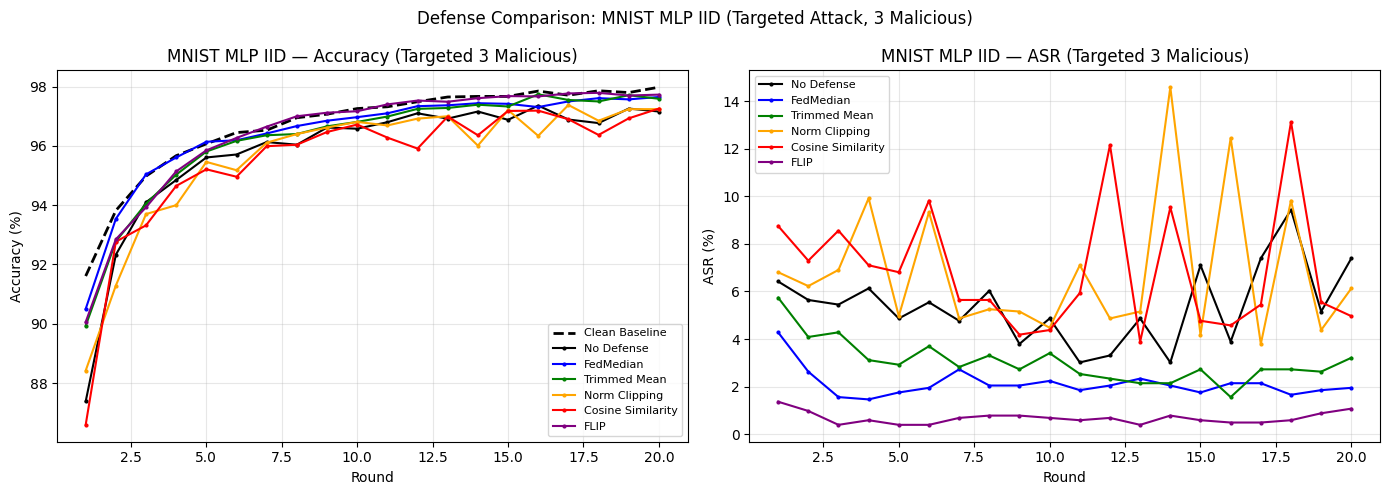

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(rounds, get_acc(mnist_mlp_iid_clean), 'k--', linewidth=2, label='Clean Baseline')
for d in defenses:
    axes[0].plot(rounds, get_acc(mnist_mlp_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[0].set_title('MNIST MLP IID — Accuracy (Targeted 3 Malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ASR
for d in defenses:
    axes[1].plot(rounds, get_asr(mnist_mlp_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[1].set_title('MNIST MLP IID — ASR (Targeted 3 Malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Defense Comparison: MNIST MLP IID (Targeted Attack, 3 Malicious)')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_mnist_mlp_iid_t3.png'), dpi=150)
plt.show()

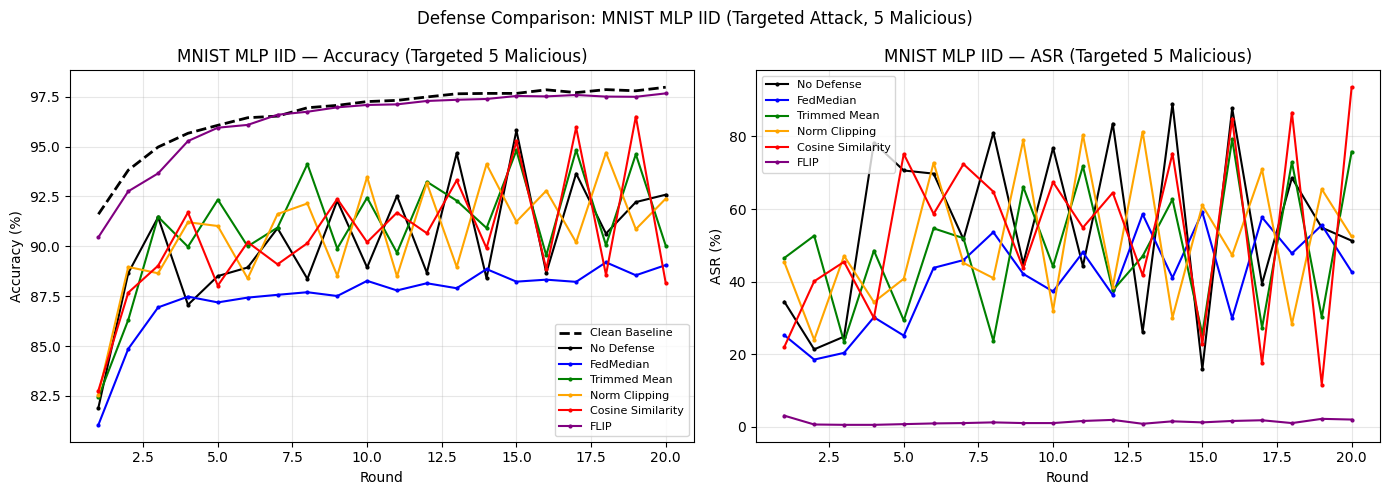

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, get_acc(mnist_mlp_iid_clean), 'k--', linewidth=2, label='Clean Baseline')
for d in defenses:
    axes[0].plot(rounds, get_acc(mnist_mlp_iid_t5[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[0].set_title('MNIST MLP IID — Accuracy (Targeted 5 Malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for d in defenses:
    axes[1].plot(rounds, get_asr(mnist_mlp_iid_t5[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[1].set_title('MNIST MLP IID — ASR (Targeted 5 Malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Defense Comparison: MNIST MLP IID (Targeted Attack, 5 Malicious)')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_mnist_mlp_iid_t5.png'), dpi=150)
plt.show()

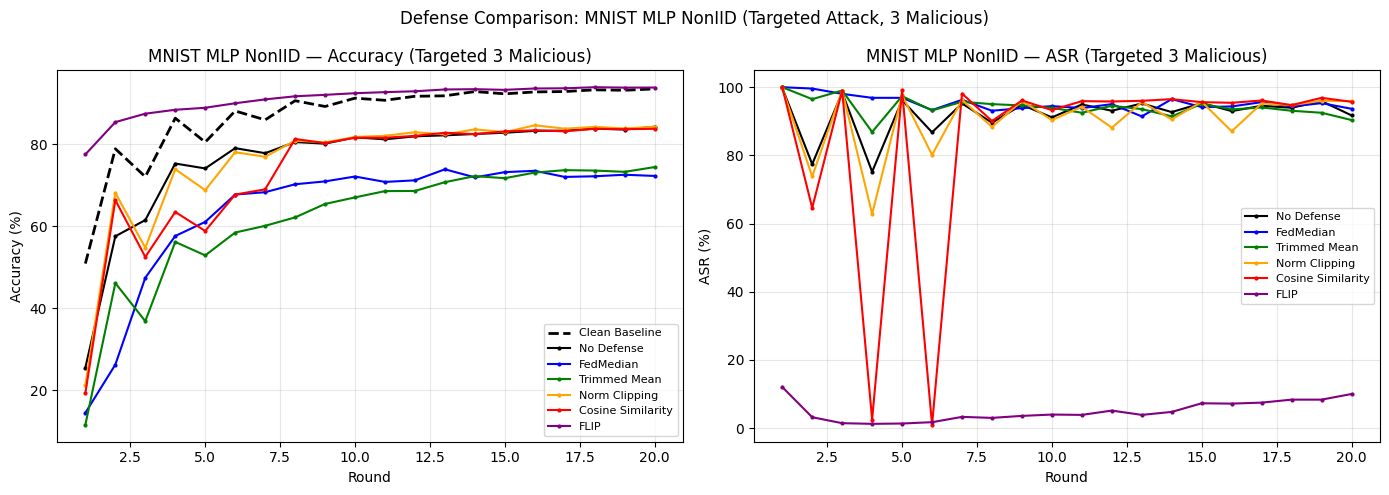

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, get_acc(mnist_mlp_noniid_clean), 'k--', linewidth=2, label='Clean Baseline')
for d in defenses:
    axes[0].plot(rounds, get_acc(mnist_mlp_noniid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[0].set_title('MNIST MLP NonIID — Accuracy (Targeted 3 Malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for d in defenses:
    axes[1].plot(rounds, get_asr(mnist_mlp_noniid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[1].set_title('MNIST MLP NonIID — ASR (Targeted 3 Malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Defense Comparison: MNIST MLP NonIID (Targeted Attack, 3 Malicious)')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_mnist_mlp_noniid_t3.png'), dpi=150)
plt.show()

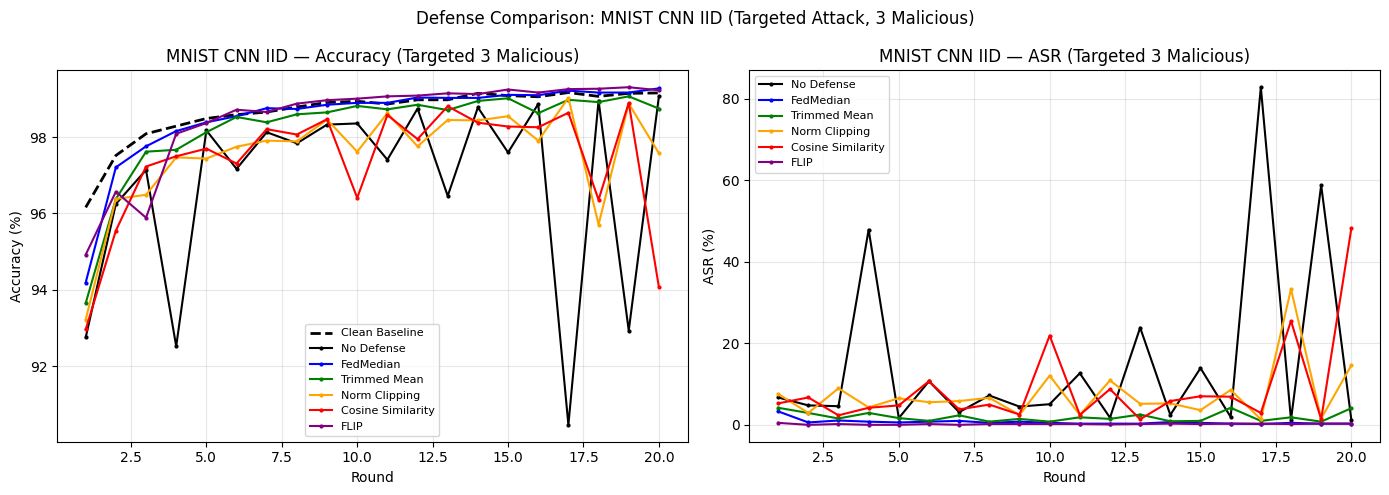

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, get_acc(mnist_cnn_iid_clean), 'k--', linewidth=2, label='Clean Baseline')
for d in defenses:
    axes[0].plot(rounds, get_acc(mnist_cnn_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[0].set_title('MNIST CNN IID — Accuracy (Targeted 3 Malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for d in defenses:
    axes[1].plot(rounds, get_asr(mnist_cnn_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[1].set_title('MNIST CNN IID — ASR (Targeted 3 Malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Defense Comparison: MNIST CNN IID (Targeted Attack, 3 Malicious)')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_mnist_cnn_iid_t3.png'), dpi=150)
plt.show()

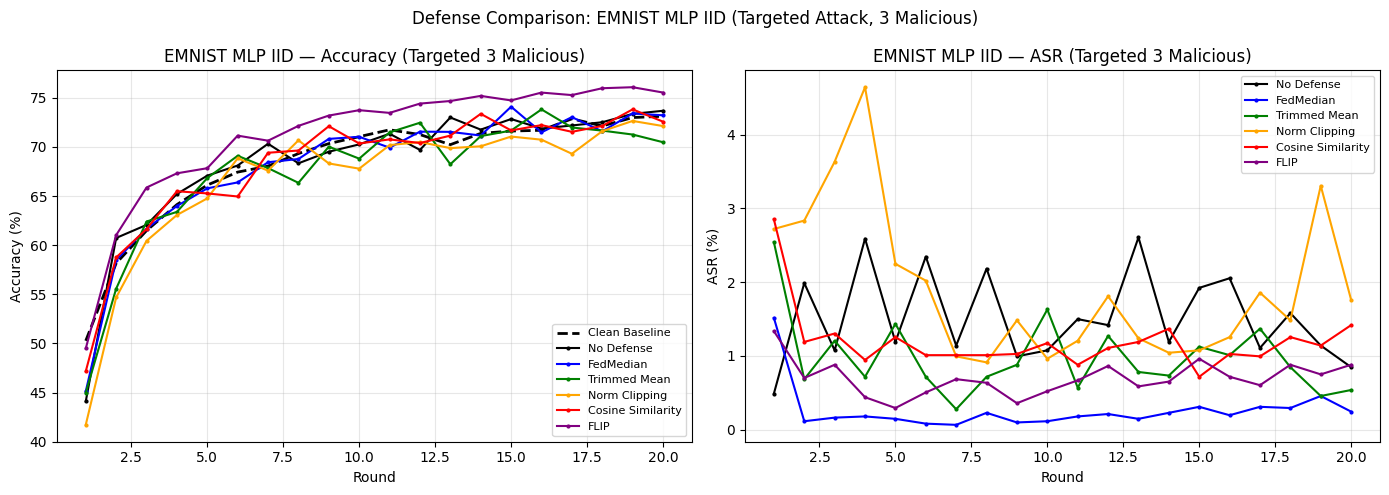

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, get_acc(emnist_mlp_iid_clean), 'k--', linewidth=2, label='Clean Baseline')
for d in defenses:
    axes[0].plot(rounds, get_acc(emnist_mlp_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[0].set_title('EMNIST MLP IID — Accuracy (Targeted 3 Malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for d in defenses:
    axes[1].plot(rounds, get_asr(emnist_mlp_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[1].set_title('EMNIST MLP IID — ASR (Targeted 3 Malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Defense Comparison: EMNIST MLP IID (Targeted Attack, 3 Malicious)')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_emnist_mlp_iid_t3.png'), dpi=150)
plt.show()

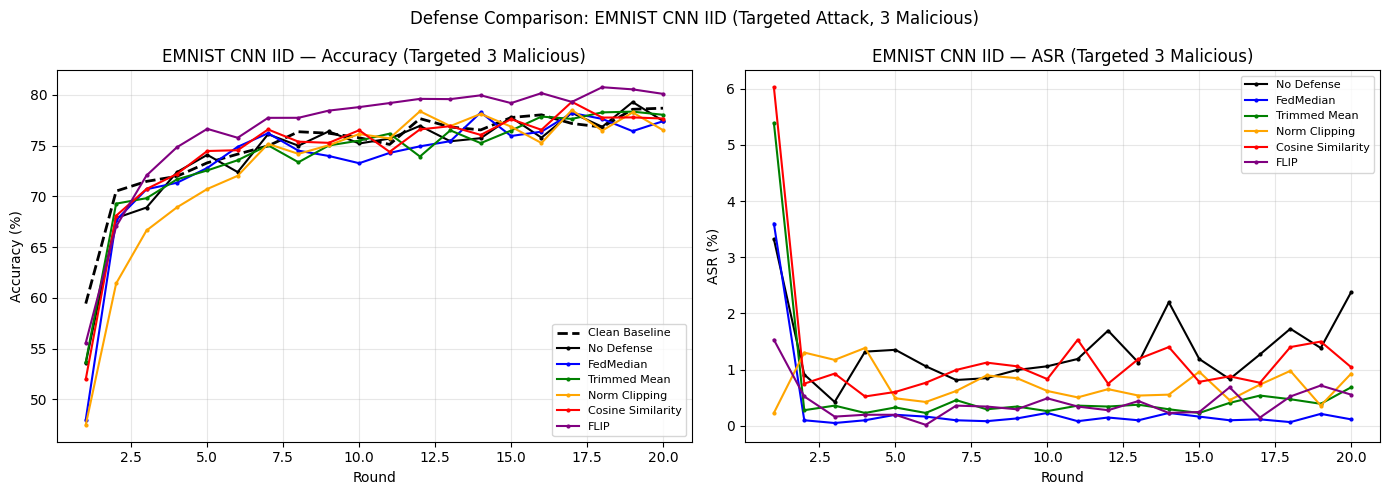

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, get_acc(emnist_cnn_iid_clean), 'k--', linewidth=2, label='Clean Baseline')
for d in defenses:
    axes[0].plot(rounds, get_acc(emnist_cnn_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[0].set_title('EMNIST CNN IID — Accuracy (Targeted 3 Malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for d in defenses:
    axes[1].plot(rounds, get_asr(emnist_cnn_iid_t3[d]),
                 color=colors[d], linewidth=1.5, marker='o', markersize=2, label=labels[d])
axes[1].set_title('EMNIST CNN IID — ASR (Targeted 3 Malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Defense Comparison: EMNIST CNN IID (Targeted Attack, 3 Malicious)')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_emnist_cnn_iid_t3.png'), dpi=150)
plt.show()

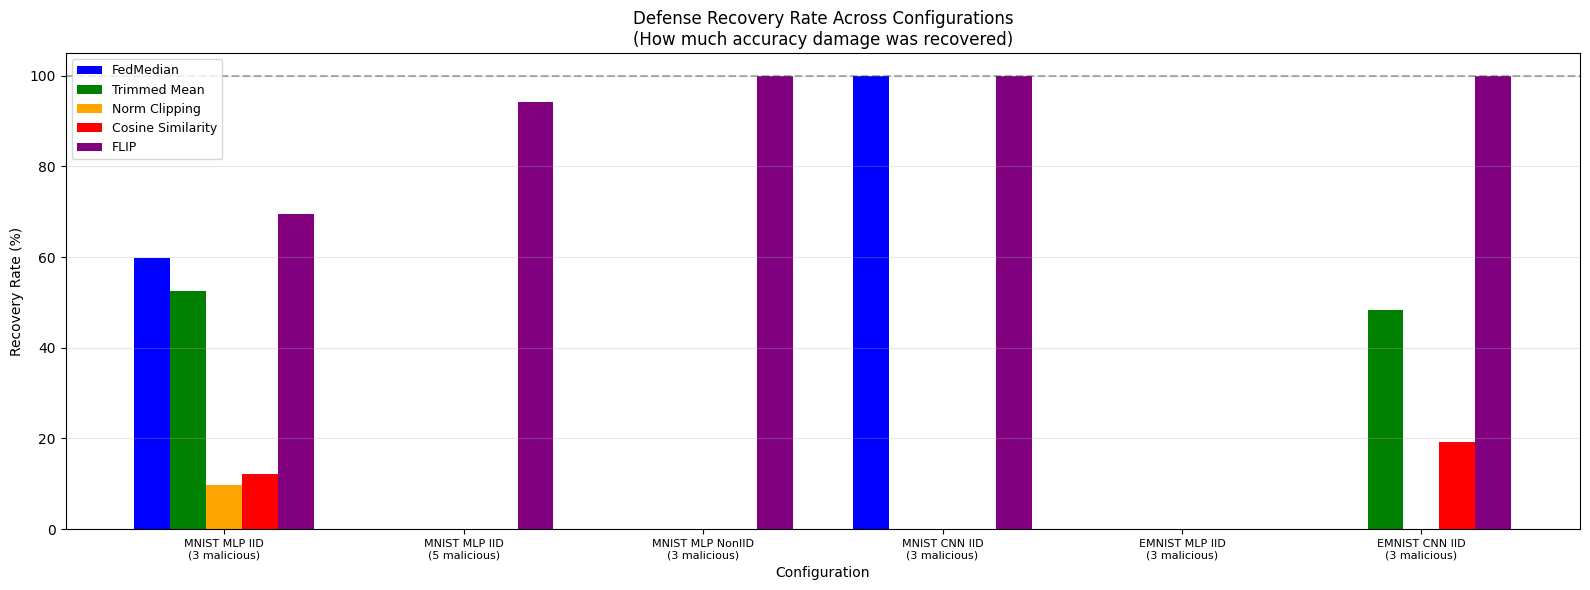

In [9]:
configs = {
    'MNIST MLP IID\n(3 malicious)' : (mnist_mlp_iid_t3,    final_acc(mnist_mlp_iid_clean)),
    'MNIST MLP IID\n(5 malicious)' : (mnist_mlp_iid_t5,    final_acc(mnist_mlp_iid_clean)),
    'MNIST MLP NonIID\n(3 malicious)': (mnist_mlp_noniid_t3, final_acc(mnist_mlp_noniid_clean)),
    'MNIST CNN IID\n(3 malicious)' : (mnist_cnn_iid_t3,    final_acc(mnist_cnn_iid_clean)),
    'EMNIST MLP IID\n(3 malicious)': (emnist_mlp_iid_t3,   final_acc(emnist_mlp_iid_clean)),
    'EMNIST CNN IID\n(3 malicious)': (emnist_cnn_iid_t3,   final_acc(emnist_cnn_iid_clean)),
}

defense_list = ['fed_median', 'trimmed_mean', 'norm_clipping', 'cosine_similarity', 'flip']
x = np.arange(len(configs))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))

for i, d in enumerate(defense_list):
    recovery_rates = []
    for cfg_name, (cfg_data, clean_acc) in configs.items():
        attack_acc  = final_acc(cfg_data['none'])
        defense_acc = final_acc(cfg_data[d])
        damage      = clean_acc - attack_acc
        recovery    = defense_acc - attack_acc
        rate        = (recovery / damage * 100) if damage > 0 else 0
        rate        = max(0, min(rate, 100))
        recovery_rates.append(rate)
    ax.bar(x + i*width, recovery_rates, width, label=labels[d], color=list(colors.values())[i+1])

ax.set_xlabel('Configuration')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Defense Recovery Rate Across Configurations\n(How much accuracy damage was recovered)')
ax.set_xticks(x + width*2)
ax.set_xticklabels(configs.keys(), fontsize=8)
ax.legend(fontsize=9)
ax.axhline(y=100, color='black', linestyle='--', alpha=0.3, label='Full recovery')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_recovery_rate.png'), dpi=150)
plt.show()

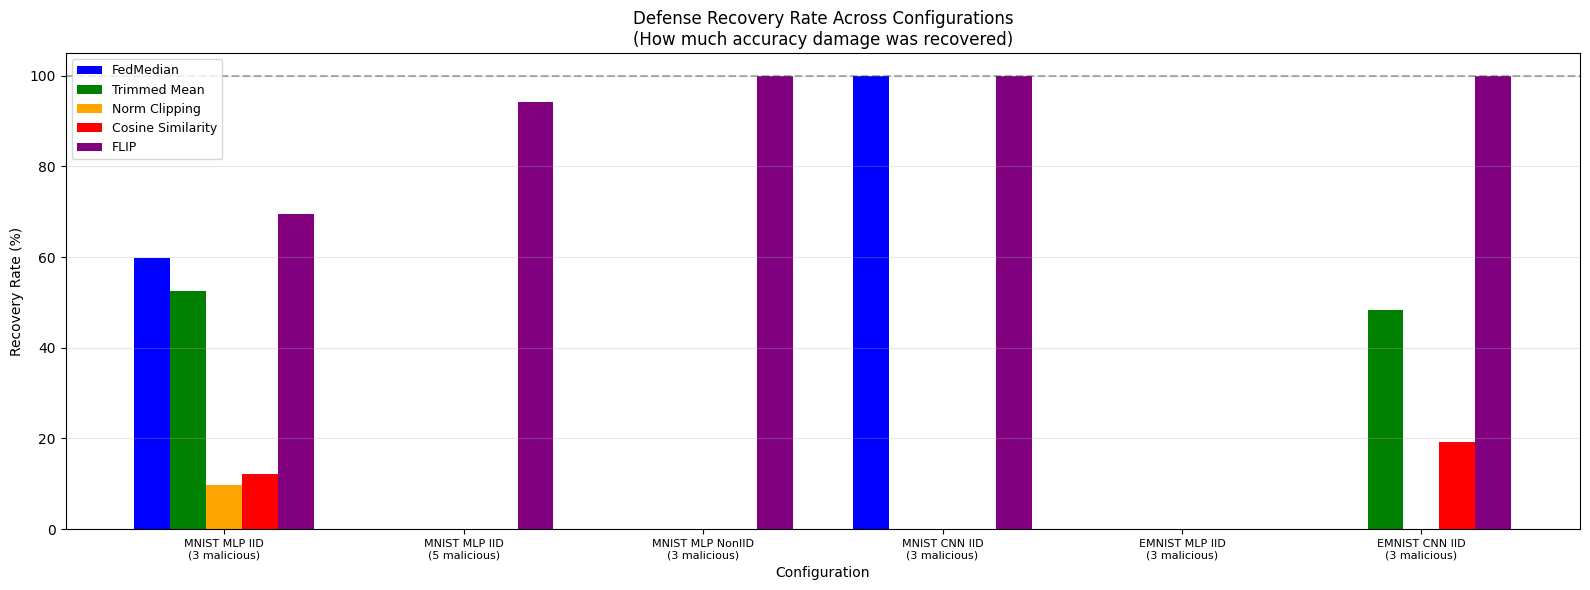

In [10]:
configs = {
    'MNIST MLP IID\n(3 malicious)' : (mnist_mlp_iid_t3,    final_acc(mnist_mlp_iid_clean)),
    'MNIST MLP IID\n(5 malicious)' : (mnist_mlp_iid_t5,    final_acc(mnist_mlp_iid_clean)),
    'MNIST MLP NonIID\n(3 malicious)': (mnist_mlp_noniid_t3, final_acc(mnist_mlp_noniid_clean)),
    'MNIST CNN IID\n(3 malicious)' : (mnist_cnn_iid_t3,    final_acc(mnist_cnn_iid_clean)),
    'EMNIST MLP IID\n(3 malicious)': (emnist_mlp_iid_t3,   final_acc(emnist_mlp_iid_clean)),
    'EMNIST CNN IID\n(3 malicious)': (emnist_cnn_iid_t3,   final_acc(emnist_cnn_iid_clean)),
}

defense_list = ['fed_median', 'trimmed_mean', 'norm_clipping', 'cosine_similarity', 'flip']
x = np.arange(len(configs))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))

for i, d in enumerate(defense_list):
    recovery_rates = []
    for cfg_name, (cfg_data, clean_acc) in configs.items():
        attack_acc  = final_acc(cfg_data['none'])
        defense_acc = final_acc(cfg_data[d])
        damage      = clean_acc - attack_acc
        recovery    = defense_acc - attack_acc
        rate        = (recovery / damage * 100) if damage > 0 else 0
        rate        = max(0, min(rate, 100))
        recovery_rates.append(rate)
    ax.bar(x + i*width, recovery_rates, width, label=labels[d], color=list(colors.values())[i+1])

ax.set_xlabel('Configuration')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Defense Recovery Rate Across Configurations\n(How much accuracy damage was recovered)')
ax.set_xticks(x + width*2)
ax.set_xticklabels(configs.keys(), fontsize=8)
ax.legend(fontsize=9)
ax.axhline(y=100, color='black', linestyle='--', alpha=0.3, label='Full recovery')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_recovery_rate.png'), dpi=150)
plt.show()

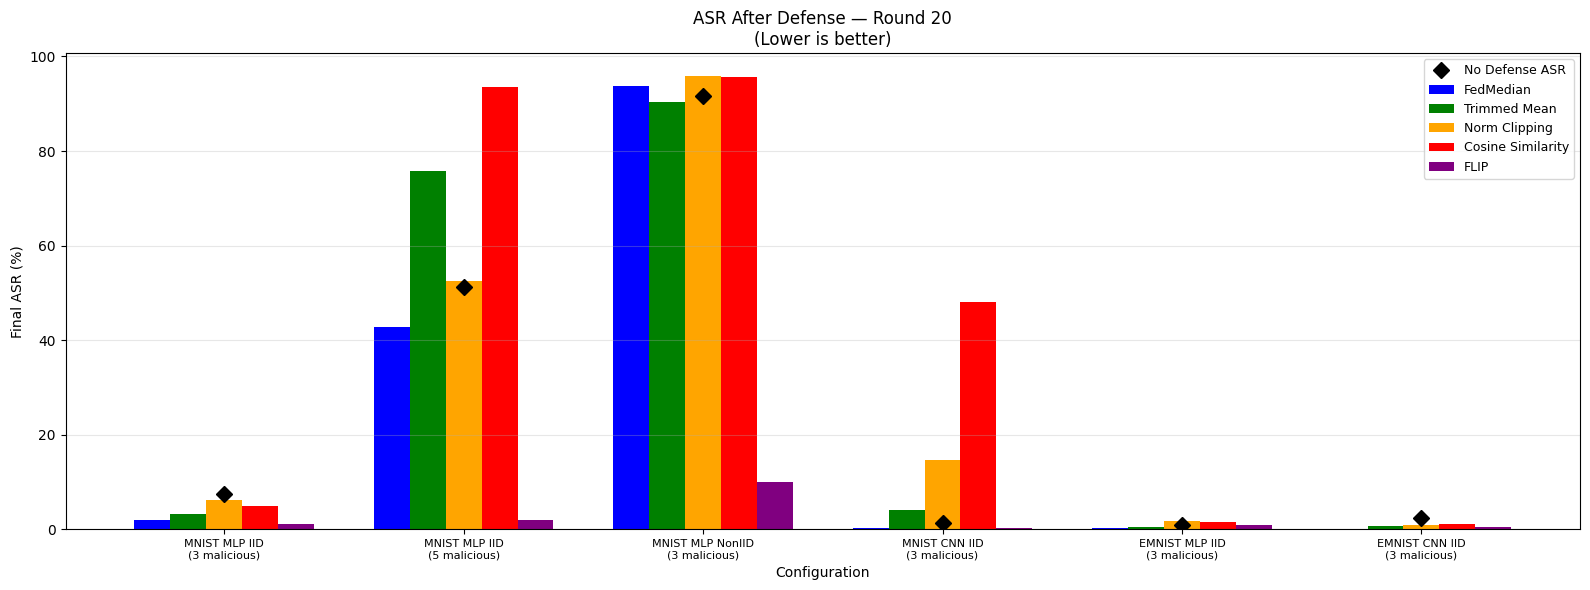

In [11]:
fig, ax = plt.subplots(figsize=(16, 6))

for i, d in enumerate(defense_list):
    asr_values = []
    for cfg_name, (cfg_data, clean_acc) in configs.items():
        asr_values.append(final_asr(cfg_data[d]))
    ax.bar(x + i*width, asr_values, width, label=labels[d], color=list(colors.values())[i+1])

# Also plot no-defense ASR
no_defense_asr = [final_asr(cfg_data['none']) for _, (cfg_data, _) in configs.items()]
ax.plot(x + width*2, no_defense_asr, 'kD', markersize=8, label='No Defense ASR', zorder=5)

ax.set_xlabel('Configuration')
ax.set_ylabel('Final ASR (%)')
ax.set_title('ASR After Defense — Round 20\n(Lower is better)')
ax.set_xticks(x + width*2)
ax.set_xticklabels(configs.keys(), fontsize=8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_asr_reduction.png'), dpi=150)
plt.show()

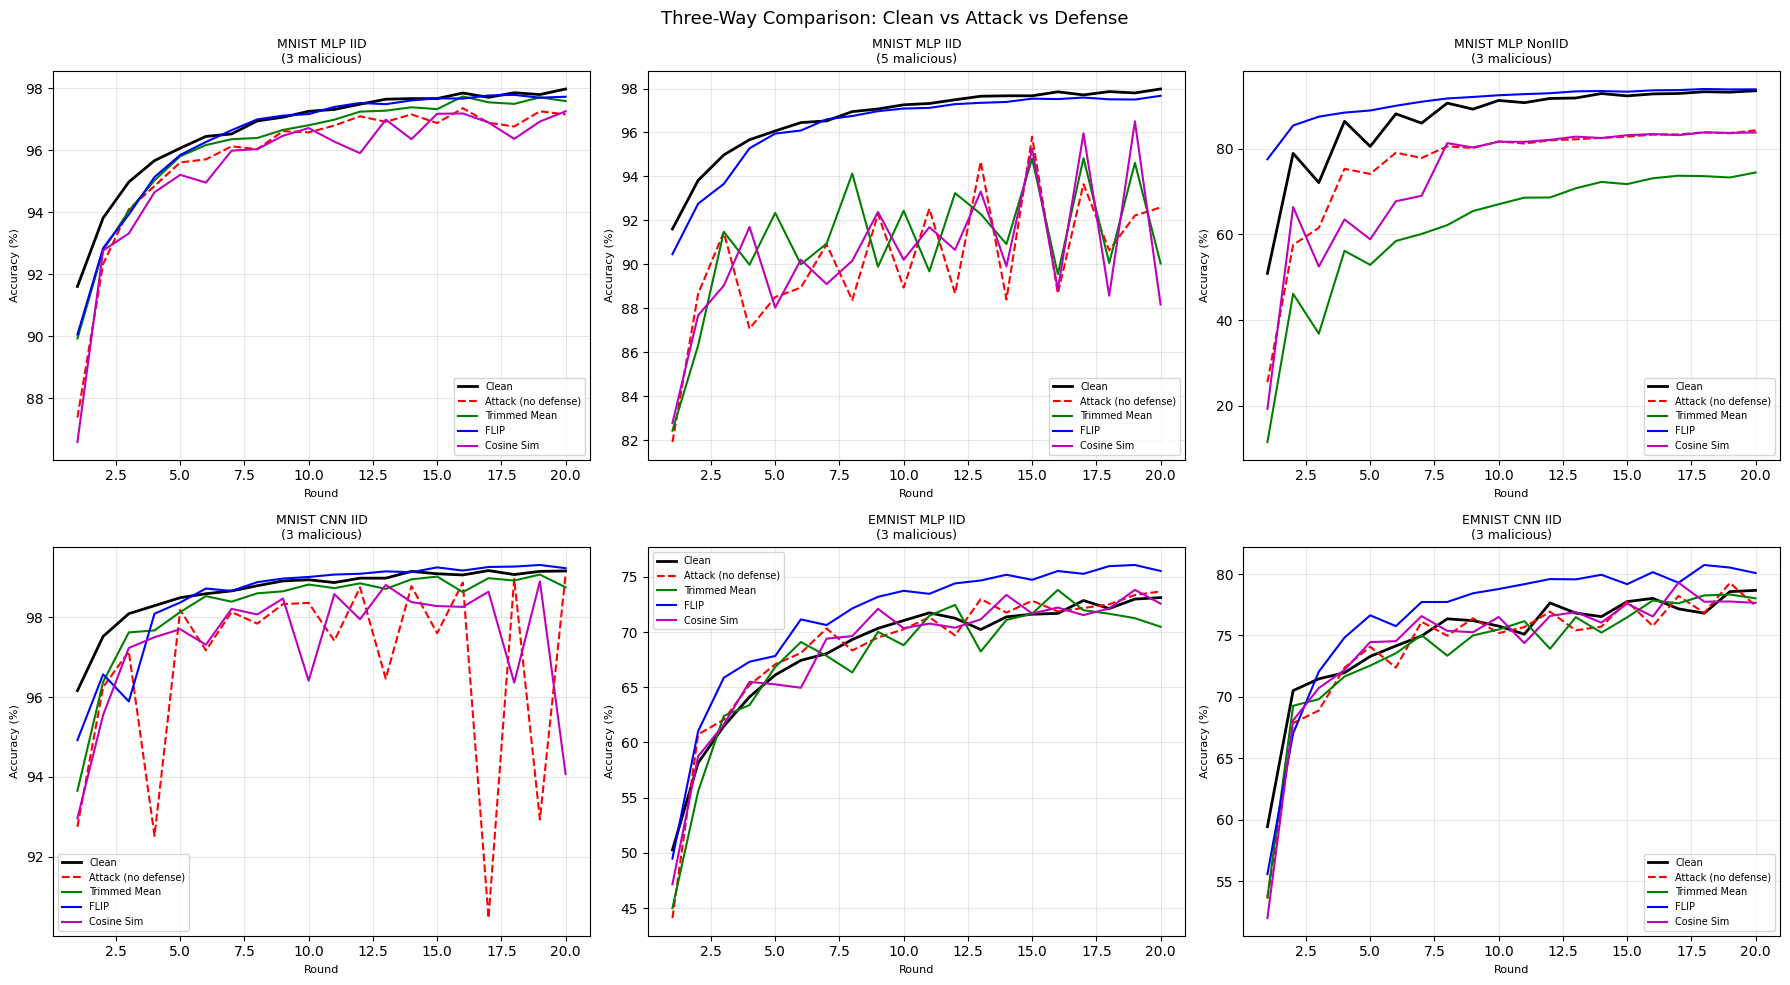

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_configs = [
    ('MNIST MLP IID\n(3 malicious)',  mnist_mlp_iid_t3,    mnist_mlp_iid_clean),
    ('MNIST MLP IID\n(5 malicious)',  mnist_mlp_iid_t5,    mnist_mlp_iid_clean),
    ('MNIST MLP NonIID\n(3 malicious)', mnist_mlp_noniid_t3, mnist_mlp_noniid_clean),
    ('MNIST CNN IID\n(3 malicious)',  mnist_cnn_iid_t3,    mnist_cnn_iid_clean),
    ('EMNIST MLP IID\n(3 malicious)', emnist_mlp_iid_t3,   emnist_mlp_iid_clean),
    ('EMNIST CNN IID\n(3 malicious)', emnist_cnn_iid_t3,   emnist_cnn_iid_clean),
]

for ax, (title, cfg_data, clean_data) in zip(axes.flatten(), plot_configs):
    ax.plot(rounds, get_acc(clean_data),         'k-',  linewidth=2, label='Clean')
    ax.plot(rounds, get_acc(cfg_data['none']),   'r--', linewidth=1.5, label='Attack (no defense)')
    ax.plot(rounds, get_acc(cfg_data['trimmed_mean']), 'g-', linewidth=1.5, label='Trimmed Mean')
    ax.plot(rounds, get_acc(cfg_data['flip']),   'b-',  linewidth=1.5, label='FLIP')
    ax.plot(rounds, get_acc(cfg_data['cosine_similarity']), 'm-', linewidth=1.5, label='Cosine Sim')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Round', fontsize=8)
    ax.set_ylabel('Accuracy (%)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Three-Way Comparison: Clean vs Attack vs Defense', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_threeway_comparison.png'), dpi=150)
plt.show()

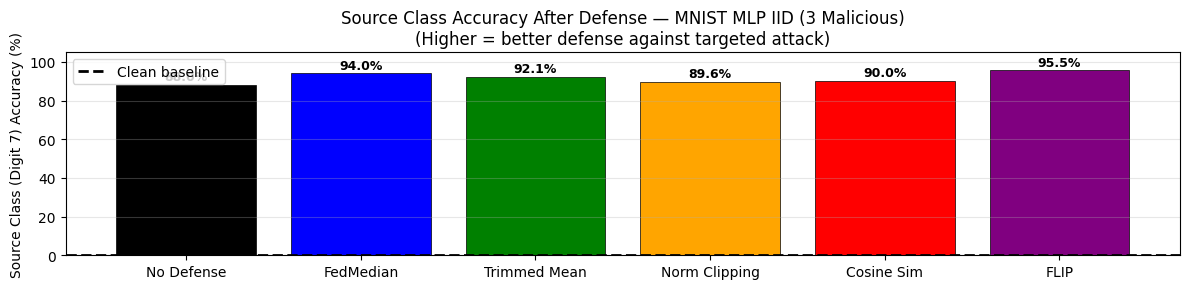

In [13]:
defense_names = ['No Defense', 'FedMedian', 'Trimmed Mean', 'Norm Clipping', 'Cosine Sim', 'FLIP']
defense_keys  = ['none', 'fed_median', 'trimmed_mean', 'norm_clipping', 'cosine_similarity', 'flip']

src_class_acc = [final_src_class(mnist_mlp_iid_t3[d], src=7) for d in defense_keys]

fig, ax = plt.subplots(figsize=(12, 3))
bars = ax.bar(defense_names, src_class_acc,
              color=[colors[d] for d in defense_keys], edgecolor='black', linewidth=0.5)
ax.axhline(y=final_src_class(mnist_mlp_iid_clean, src=7),
           color='black', linestyle='--', linewidth=2, label='Clean baseline')
ax.set_ylabel('Source Class (Digit 7) Accuracy (%)')
ax.set_title('Source Class Accuracy After Defense — MNIST MLP IID (3 Malicious)\n(Higher = better defense against targeted attack)')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, src_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(base_attack, 'defense_source_class_recovery.png'), dpi=150)
plt.show()

In [14]:
print("=" * 95)
print(f"{'Configuration':<30} {'Defense':<18} {'Accuracy':>10} {'ASR':>8} {'Src Cls':>8} {'Recovery':>10}")
print("=" * 95)

for cfg_name, (cfg_data, clean_acc) in configs.items():
    cfg_short = cfg_name.replace('\n', ' ')
    attack_acc = final_acc(cfg_data['none'])
    damage     = clean_acc - attack_acc

    for d in ['none'] + defense_list:
        acc      = final_acc(cfg_data[d])
        asr      = final_asr(cfg_data[d])
        src_cls  = final_src_class(cfg_data[d], src=7)
        recovery = ((acc - attack_acc) / damage * 100) if (damage > 0 and d != 'none') else 0
        rec_str  = f"{recovery:.1f}%" if d != 'none' else "—"
        def_str  = labels[d]
        cfg_str  = cfg_short if d == 'none' else ''
        print(f"{cfg_str:<30} {def_str:<18} {acc:>9.2f}% {asr:>7.2f}% {src_cls:>7.2f}% {rec_str:>10}")
    print("-" * 95)

print("=" * 95)

Configuration                  Defense              Accuracy      ASR  Src Cls   Recovery
MNIST MLP IID (3 malicious)    No Defense             97.16%    7.39%   88.04%          —
                               FedMedian              97.65%    1.95%   93.97%      59.8%
                               Trimmed Mean           97.59%    3.21%   92.12%      52.4%
                               Norm Clipping          97.24%    6.13%   89.59%       9.8%
                               Cosine Similarity      97.26%    4.96%   89.98%      12.2%
                               FLIP                   97.73%    1.07%   95.53%      69.5%
-----------------------------------------------------------------------------------------------
MNIST MLP IID (5 malicious)    No Defense             92.59%   51.26%   43.39%          —
                               FedMedian              89.06%   42.70%    9.82%     -65.5%
                               Trimmed Mean           90.04%   75.78%   19.26%     -47.3%
    